<a href="https://colab.research.google.com/github/KuldeepIsharwal/Machine-Learning-Basics/blob/main/Outliars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Outlier

A data point that differs significantly from other observations in the dataset — lying an abnormal distance from the bulk of the data.

Linear models (Linear Regression, SVM) are highly sensitive — one extreme value can pull the entire fit
Distance-based models (KNN, K-Means) measure proximity — outliers distort every distance calculation

#How to detect outliars

1. plot a normal distribution and anything beyond mean +- 3*SD is outliar

2. for skewed data : IQR

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

#How to treat outliars


1.   Trimming (remove them)
2.   Capping
3.   consider them missing / discretization  (less used)


#Outliar removal using z-score

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/placement.csv')

In [3]:
df.sample(5)

,cgpa,placement_exam_marks,placed
220,7.75,16.0,1
697,7.23,49.0,1
229,6.68,13.0,0
433,5.77,11.0,1
740,6.21,74.0,1


In [4]:
df.isnull().sum()

,0
cgpa,0
placement_exam_marks,0
placed,0


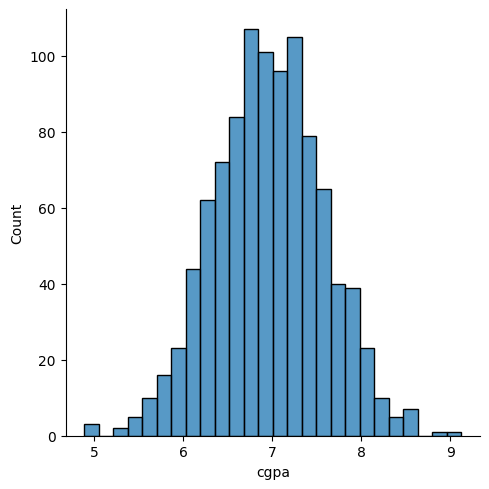

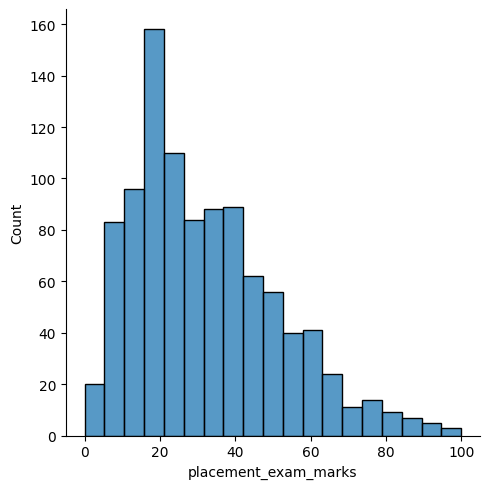

In [5]:
sns.displot(df['cgpa'])
sns.displot(df['placement_exam_marks'])

In [6]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [7]:

df[(df['cgpa'] >df['cgpa'].mean() + 3 * df['cgpa'].std()) | (df['cgpa'] <df['cgpa'].mean() - 3 * df['cgpa'].std() )]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


#Trimming

In [8]:
new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


#Capping

In [9]:
ul =df['cgpa'].mean() + 3 * df['cgpa'].std()
ll =df['cgpa'].mean() - 3 * df['cgpa'].std()

In [10]:
df['cgpa'] = np.where(df['cgpa'] > ul, ul, np.where(df['cgpa'] < ll, ll, df['cgpa']))

In [11]:
df.shape

(1000, 3)

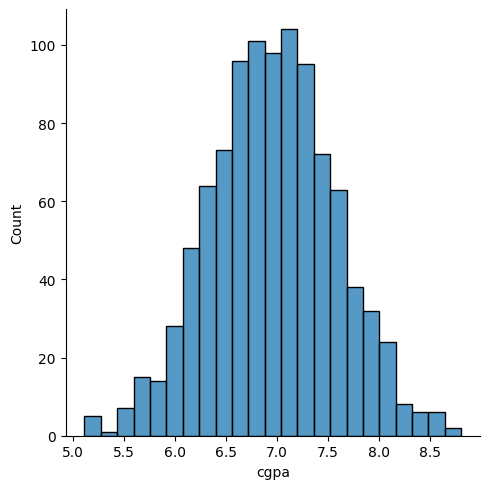

In [12]:
sns.displot(df['cgpa'])


#IQR
Now we will apply IQR on placement exam marks cz that coln is skewed

In [13]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: ylabel='placement_exam_marks'>

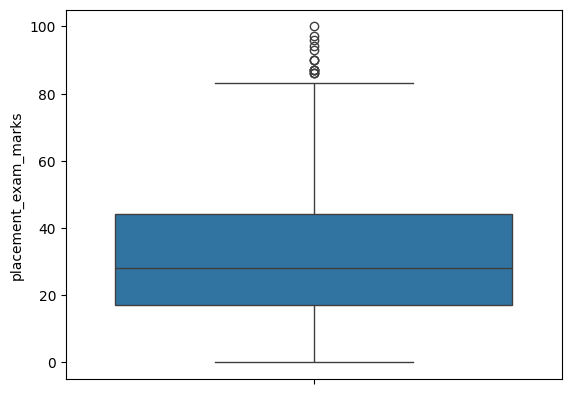

In [14]:
sns.boxplot(df['placement_exam_marks'])

In [15]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [17]:
iqr = percentile75 - percentile25

upper_bound = percentile75 + 1.5 * iqr
lower_bound = percentile25 - 1.5 * iqr

# Filter the DataFrame to remove outliers
df = df[(df['placement_exam_marks'] >= lower_bound) & (df['placement_exam_marks'] <= upper_bound)]

df.shape

(985, 3)

<Axes: ylabel='placement_exam_marks'>

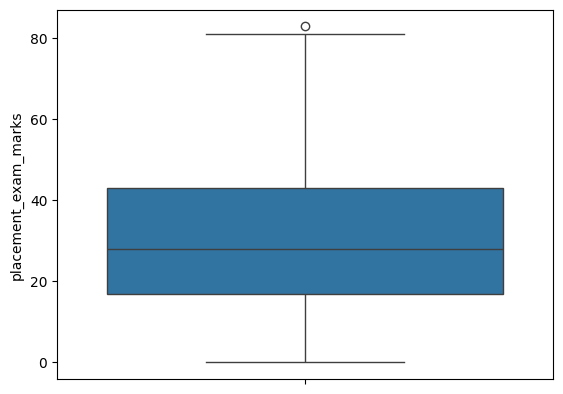

In [18]:
sns.boxplot(df['placement_exam_marks'])

Empty DataFrame
Columns: [cgpa, placement_exam_marks, placed]
Index: []
